In [11]:
# ============================================
# Blockwise permutation + Areal GP + VI module
# Using meuse_obs.zip (geopandas) & elev as X
# ============================================

from math import pi
import os
from typing import Dict, Any, Sequence

import numpy as np
import torch
import torch.optim as optim
from tqdm import tqdm

import pandas as pd
import geopandas as gpd  # <--- NEW

from GPModel import GPModel
from GPArealModel import GPArealModel
from revised_VIGP_Unlinked import VIGP_Unlinked
from utils import round_to_perm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def _to_tensor(x, dtype=torch.float32):
    if isinstance(x, torch.Tensor):
        return x.to(device=device, dtype=dtype)
    return torch.as_tensor(x, device=device, dtype=dtype)


# ---------------------------------------------------------
# STEP 2 helper: construct blockwise permutation at data level
# ---------------------------------------------------------

def make_blockwise_permuted_data(
    coords,
    X,
    Y,
    n_blocks: int = 15,
    n_locations: int = 10,
    n_drop: int = 5,
    seed: int = 51,
) -> Dict[str, torch.Tensor]:
    """
    Prepare original (restricted) and blockwise-permuted data.

    This version:
      1. randomly removes n_drop locations,
      2. uses the remaining N_use = n_blocks * n_locations observations,
      3. sorts by first coordinate before forming contiguous blocks.

    Returns a dict with:
        coords_orig, X_orig, Y_orig   : restricted, sorted (unpermuted)
        coords_perm, X_perm, Y_perm   : permuted inside blocks
        region_assignments            : (N_use,) with values 0,...,B-1
        perm_matrix_x, perm_matrix_s  : (n_locations, n_locations) within-block perms
        dropped_indices               : original indices that were removed
        kept_indices                  : original indices retained
    """

    torch.manual_seed(seed)
    np.random.seed(seed)

    coords = _to_tensor(coords)
    Y = _to_tensor(Y).view(-1)
    X = _to_tensor(X)

    if X.ndim == 1:
        X = X.unsqueeze(1)

    N_total = coords.shape[0]
    N_use = n_blocks * n_locations

    if N_total < N_use + n_drop:
        raise ValueError(
            f"Not enough locations: N={N_total}, need at least {N_use + n_drop} "
            f"for n_blocks={n_blocks}, n_locations={n_locations}, n_drop={n_drop}."
        )

    # -----------------------------------------------------
    # 1. Remove n_drop locations uniformly at random
    # -----------------------------------------------------
    all_idx = torch.randperm(N_total, device=device)
    dropped_indices = all_idx[:n_drop]
    kept_indices = all_idx[n_drop:]

    #print dropped indices
    print(f"Dropped indices: {dropped_indices.cpu().numpy()}")

    coords_kept = coords[kept_indices]
    X_kept = X[kept_indices]
    Y_kept = Y[kept_indices]

    # -----------------------------------------------------
    # 2. Sort kept points by first coordinate, then keep N_use
    # -----------------------------------------------------
    sort_idx_local = torch.argsort(coords_kept[:, 0])
    sort_idx_local = sort_idx_local[:N_use]

    coords_orig = coords_kept[sort_idx_local].contiguous()
    X_orig = X_kept[sort_idx_local].contiguous()
    Y_orig = Y_kept[sort_idx_local].contiguous()

    kept_indices = kept_indices[sort_idx_local]

    N = N_use

    # -----------------------------------------------------
    # 3. Region assignments: contiguous blocks of size n_locations
    # -----------------------------------------------------
    region_assignments = torch.zeros(N, dtype=torch.long, device=device)
    for b in range(n_blocks):
        start = b * n_locations
        end = (b + 1) * n_locations
        region_assignments[start:end] = b

    # -----------------------------------------------------
    # 4. Shared within-block permutations
    # -----------------------------------------------------
    def random_derangement(n, device=None):
        if n < 2:
            raise ValueError("A derangement is impossible when n < 2.")
        
        base = torch.arange(n, device=device)
        while True:
            perm = torch.randperm(n, device=device)
            if torch.all(perm != base):
                return perm

    perm_x = random_derangement(n_locations, device=device)
    perm_s = random_derangement(n_locations, device=device)
    
    perm_matrix_x = torch.zeros(
        n_locations, n_locations, dtype=torch.float32, device=device
    )
    perm_matrix_x[torch.arange(n_locations, device=device), perm_x] = 1.0

    perm_matrix_s = torch.zeros(
        n_locations, n_locations, dtype=torch.float32, device=device
    )
    perm_matrix_s[torch.arange(n_locations, device=device), perm_s] = 1.0

    # -----------------------------------------------------
    # 5. Apply blockwise permutations
    # -----------------------------------------------------
    X_perm = torch.zeros_like(X_orig)
    coords_perm = torch.zeros_like(coords_orig)

    for b in range(n_blocks):
        start = b * n_locations
        end = (b + 1) * n_locations

        X_perm[start:end] = X_orig[start:end][perm_x]
        coords_perm[start:end] = coords_orig[start:end][perm_s]

    # Y stays fixed
    Y_perm = Y_orig.clone()

    return {
        "coords_orig": coords_orig,
        "X_orig": X_orig,
        "Y_orig": Y_orig,
        "coords_perm": coords_perm,
        "X_perm": X_perm,
        "Y_perm": Y_perm,
        "region_assignments": region_assignments,
        "perm_matrix_x": perm_matrix_x,
        "perm_matrix_s": perm_matrix_s,
        "dropped_indices": dropped_indices,
        "kept_indices": kept_indices,
    }


# ---------------------------------------------------------
# STEP 3a: Areal GP ONLY (disentangled)
# ---------------------------------------------------------

def run_areal_gp(
    coords_perm: torch.Tensor,
    X_perm: torch.Tensor,
    Y_perm: torch.Tensor,
    region_assignments: torch.Tensor,
    n_blocks: int,
    n_locations: int,
    seed: int = 521,
    max_iter: int = 200,
    tol: float = 1e-4,
    W: int = 10,
) -> Dict[str, Any]:
    """
    Run GPArealModel (areal GP) on block-averaged data,
    using permuted coordinates and block structure.
    """

    torch.manual_seed(seed)
    np.random.seed(seed)

    coords_perm = _to_tensor(coords_perm)
    Y_perm = _to_tensor(Y_perm).view(-1)
    X_perm = _to_tensor(X_perm)

    if X_perm.ndim == 1:
        X_perm = X_perm.unsqueeze(1)
    p = X_perm.shape[1]
    if p != 1:
        raise ValueError(f"GPArealModel wrapper assumes scalar X (p=1), got p={p}.")

    region_assignments = region_assignments.to(device=device, dtype=torch.long)

    N = coords_perm.shape[0]
    assert N == n_blocks * n_locations, "N must equal n_blocks * n_locations."

    # Block averages of X and Y
    ybar = torch.zeros(n_blocks, device=device)
    xbar = torch.zeros(n_blocks, p, device=device)

    for b in range(n_blocks):
        start = b * n_locations
        end = (b + 1) * n_locations
        idx = torch.arange(start, end, device=device)
        ybar[b] = Y_perm[idx].mean()
        xbar[b] = X_perm[idx].mean(dim=0)

    
    gpa = GPArealModel().to(device)
    opt = optim.AdamW(gpa.parameters(), lr=0.01, weight_decay=0.01)

    gpa_loss_history = []

    for it in tqdm(range(max_iter), desc="Train GPArealModel"):
        opt.zero_grad(set_to_none=True)
        loss = gpa(coords_perm, region_assignments, xbar, ybar)
        loss.backward()
        opt.step()

        cur = float(loss.detach().item())
        gpa_loss_history.append(cur)

        if it > W:
            recent = gpa_loss_history[-W:]
            rel_range = (max(recent) - min(recent)) / (abs(recent[-1]) + 1e-12)
            if rel_range < tol:
                print(f"[Stop GPA] plateau over last {W} iters at it={it}, loss={cur:.6f}")
                break


    return {
        "loss_history": gpa_loss_history,
        "nu": float(gpa.nu.item()),
        "phi": float(np.exp(gpa.logphi.item())),
        "sigmasq": float(np.exp(gpa.logsigmasq.item())),
        "tausq": float(np.exp(gpa.logtausq.item())),
        "beta": gpa.beta.detach().cpu().numpy(),
    }


# ---------------------------------------------------------
# STEP 3b: VI for Unlinked GP ONLY (disentangled)
# ---------------------------------------------------------

def run_vi_unlinked(
    coords_perm: torch.Tensor,
    X_perm: torch.Tensor,
    Y_perm: torch.Tensor,
    n_blocks: int,
    n_locations: int,
    seed: int = 521,
    niter_VI: int = 100,
    phi_prior_ub: float = 0.5,
    phi_prior_lb: float = 0.0,
    lr_piS=0.01,
    lr_piX=0.01,
    VX_ub: float = 0.5,
    VS_ub: float = 0.5,
    pi_X_true = None,
    pi_S_true = None
) -> Dict[str, Any]:
    """
    Run VIGP_Unlinked (VI for unlinked GP) on blockwise permuted X,Y,S.

    Returns a dict with VI outputs for each tau:
        {
          "by_tau": { tau_value: vi_out, ... },
          "taus": [...],
          "prior_parameters": {...}
        }
    """

    torch.manual_seed(seed)
    np.random.seed(seed)

    coords_perm = _to_tensor(coords_perm)
    Y_perm = _to_tensor(Y_perm).view(-1)  # (N,)
    X_perm = _to_tensor(X_perm)

    if X_perm.ndim == 1:
        X_perm = X_perm.unsqueeze(1)
    p = X_perm.shape[1]
    if p != 1:
        raise ValueError(f"VI wrapper assumes scalar X (p=1), got p={p}.")



    N = coords_perm.shape[0]
    assert N == n_blocks * n_locations, "N must equal n_blocks * n_locations."

    # Distances from permuted coordinates
    Dist = torch.cdist(coords_perm, coords_perm, p=2)
    Dist = (Dist + Dist.T) / 2.0

    # Block-shaped tensors for VI
    X_blocks = X_perm.view(n_blocks, n_locations)  # (B, n_i)
    Y_blocks = Y_perm.view(n_blocks, n_locations)  # (B, n_i)

    n_steps = 50
    n_phi_samples = 200
    n_piX_sample = 50
    n_piS_sample = 50

    prior_parameters = {
        "a1": 0.1,
        "b1": 0.1,
        "a2": 0.1,
        "b2": 0.1,
        "eta_X_sq": 0.1,
        "eta_S_sq": 0.1,
        "mu_beta": 0.0,
        "sigmasq_beta": 100.0,
        "phi_prior_lb": phi_prior_lb,
        "phi_prior_ub": phi_prior_ub,
    }


    vi_results_by_tau: Dict[float, Any] = {}

    tau=0.9
    results_VI = VIGP_Unlinked(
        n_iter=niter_VI,
        n_blocks=n_blocks,
        n_locations=n_locations,
        X=X_blocks, Y=Y_blocks,
        Dist=Dist,
        n_steps=n_steps,
        n_phi_samples=n_phi_samples,
        n_piX_sample=n_piX_sample,
        tau_X=tau, tau_S=tau,
        n_piS_sample=n_piS_sample,
        seed=521,
        fix_piX=False, fix_piS=False,
        fix_mu_lambda_beta=False,
        fix_sigmasq_lambda_beta=False,
        fix_lambda_b1=False,
        lambda_b1_fixed=((n_blocks * n_locations) * 0.5 + 0.1) * 5,
        fix_lambda_b2=False,
        M_X_star_fixed=pi_X_true.T,
        M_S_star_fixed=pi_X_true.T,
        V_X_star_fixed=torch.eye(n_locations, n_locations, device=device),
        V_S_star_fixed=torch.eye(n_locations, n_locations, device=device),
        phi_init=0.1,
        mean_Rphi_inv_fixed=torch.linalg.inv(torch.exp(-4 * Dist)),
        fix_mean_Rphi_inv=False,
        pi_X_true=pi_X_true,
        pi_S_true=pi_S_true,
        VX_ub=VX_ub, VS_ub=VS_ub,
        lr_piS=lr_piS, lr_piX=lr_piX,
        prior_parameters=prior_parameters,
        anneal_every=20, use_global_tau_anneal= True, elbo_W= 5, tol=0.1, return_mu_W_Sigma=True,
    )

    return {"results": results_VI, 
        "prior_parameters": prior_parameters,
    }


# ============================================================
# Demo: FULL PIPELINE on meuse_obs.zip
# ============================================================


# __file__ is not defined in interactive environments (e.g., Jupyter notebooks).
# Fall back to the current working directory when needed.
try:
    base_dir = os.path.dirname(__file__)
except NameError:
    base_dir = os.getcwd()

MEUSE_OBS_PATH = os.path.abspath(os.path.join(
    base_dir,
    "..",
    "data", "data_analysis",
    "meuse_obs.zip",
))

meuse_obs = gpd.read_file(MEUSE_OBS_PATH)

# coords from geometry (x, y)
coords_meuse = np.column_stack(
    [meuse_obs.geometry.x.to_numpy(), meuse_obs.geometry.y.to_numpy()]
)

# response: log1p(zinc)
Y_meuse = np.log1p(meuse_obs["zinc"].to_numpy())

# scalar covariate: elevation
# (column name in this dataset is 'elev'; if it's 'elevation' on your side, change here)
#X_meuse = np.sqrt(meuse_obs["dist"].to_numpy())
X_meuse = meuse_obs["elev"].to_numpy()

# center covariate and response to zero mean
X_meuse_mean = X_meuse.mean()
Y_meuse_mean = Y_meuse.mean()

X_meuse = X_meuse - X_meuse_mean
Y_meuse = Y_meuse - Y_meuse_mean

print(f"Centered X_meuse mean: {X_meuse.mean():.6f}, Y_meuse mean: {Y_meuse.mean():.6f}")

N_meuse = coords_meuse.shape[0]
print(f"Loaded meuse_obs: N = {N_meuse}")

# Rescale coordinates for numerical stability (e.g. to km)
coords_center = coords_meuse.mean(axis=0)
coords_scaled = (coords_meuse) / 1000.0  # now roughly in km
# Normalize coordinates to [0, 1] range
coords_min = coords_meuse.min(axis=0)
coords_max = coords_meuse.max(axis=0)
coords_scaled = (coords_meuse - coords_min) / (coords_max - coords_min)

print(f"Coordinates normalized to [0, 1]: min={coords_scaled.min():.6f}, max={coords_scaled.max():.6f}")


Centered X_meuse mean: -0.000000, Y_meuse mean: 0.000000
Loaded meuse_obs: N = 155
Coordinates normalized to [0, 1]: min=0.000000, max=1.000000


In [12]:
coords_perm_data = make_blockwise_permuted_data(
    coords=coords_scaled,
    X=X_meuse,
    Y=Y_meuse,
    n_blocks=15,
    n_locations=10,
    n_drop=5,
    seed=2029,
)
coords_perm = coords_perm_data["coords_perm"]
X_perm = coords_perm_data["X_perm"]
Y_perm = coords_perm_data["Y_perm"]
region_assignments = coords_perm_data["region_assignments"]
perm_matrix_x = coords_perm_data["perm_matrix_x"]
perm_matrix_s = coords_perm_data["perm_matrix_s"]


Dropped indices: [94 41 83 71 92]


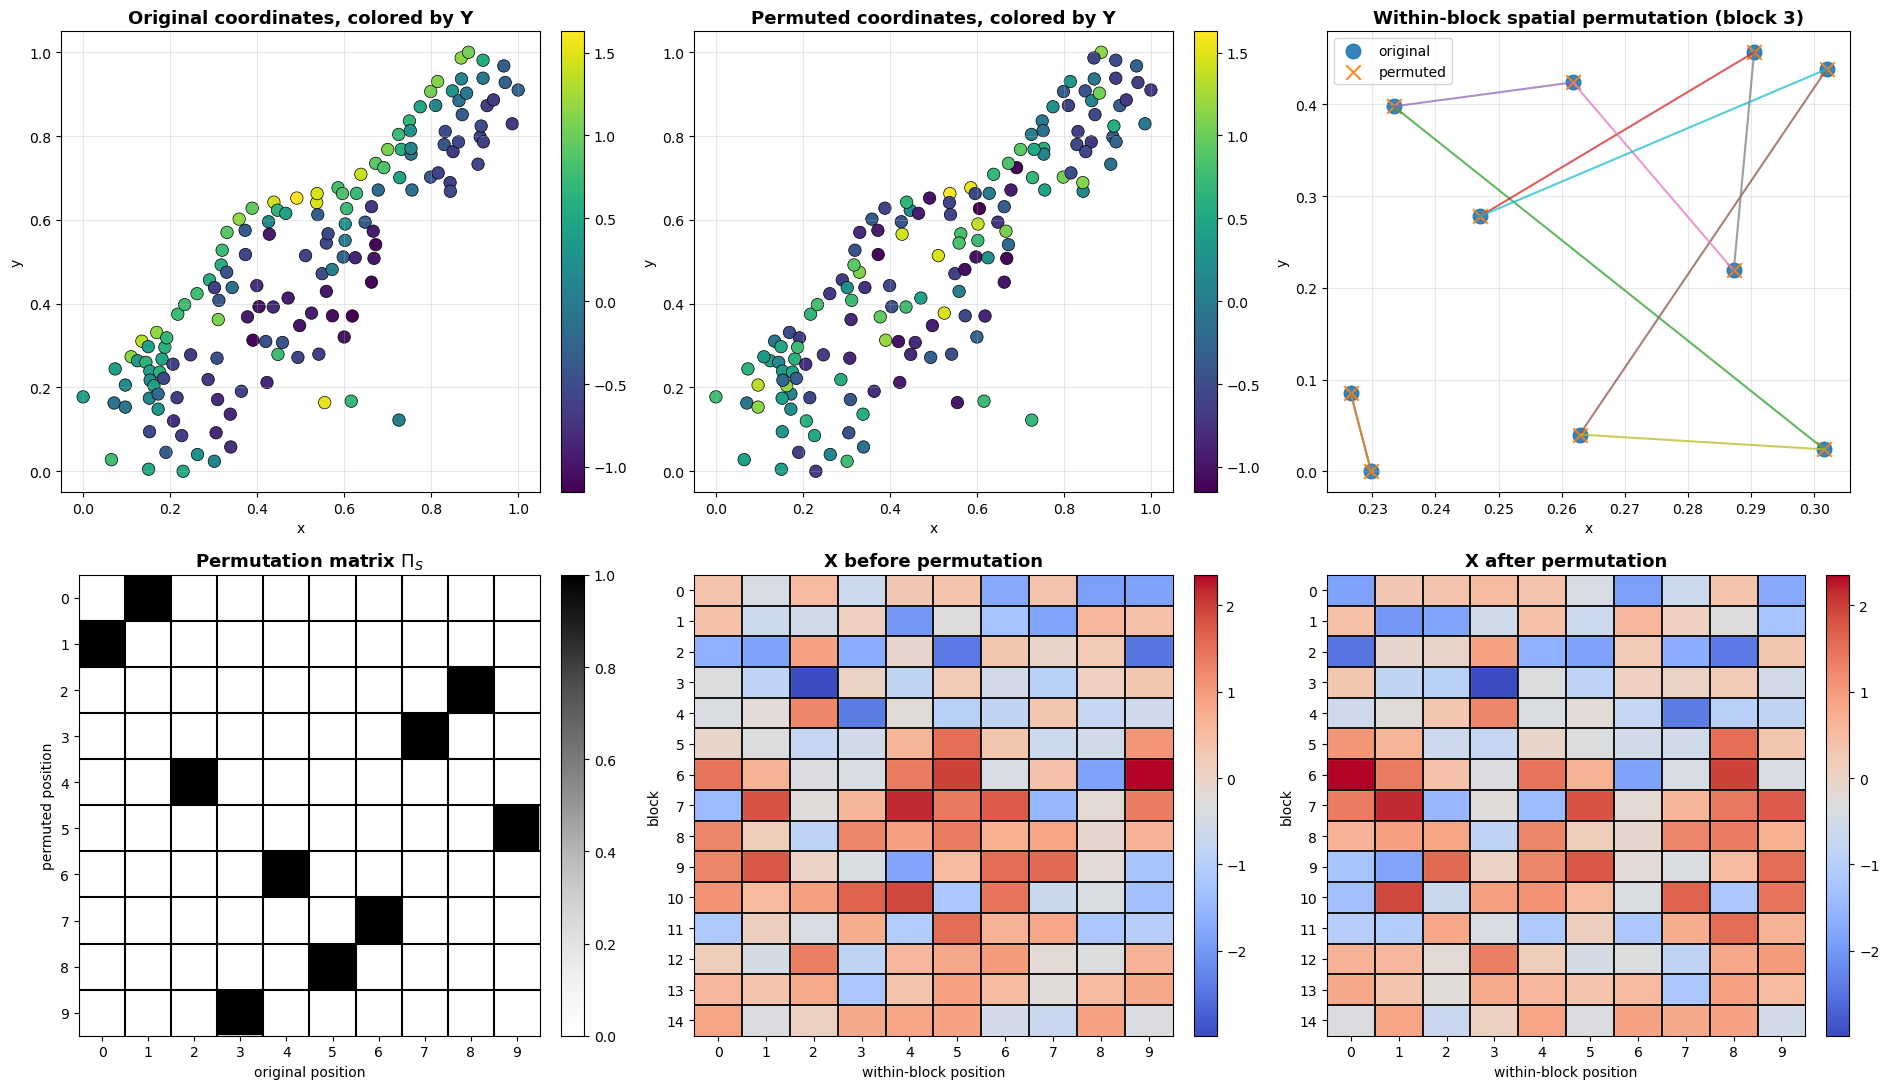

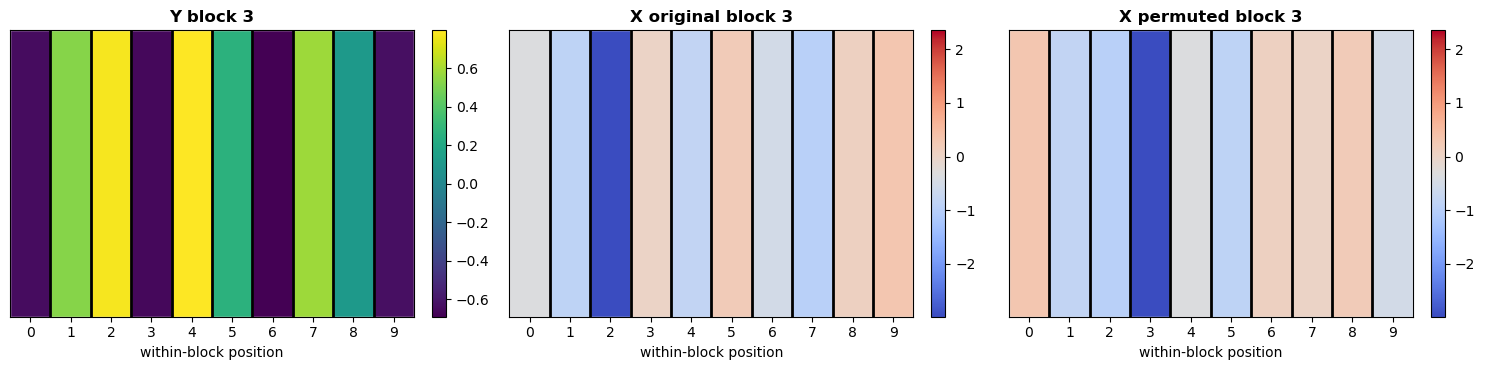

In [3]:
import matplotlib.pyplot as plt

coords_orig = coords_perm_data["coords_orig"]
X_orig = coords_perm_data["X_orig"]
Y_orig = coords_perm_data["Y_orig"]
# =========================================================
# Helper: add thin cell grid + thicker separators
# =========================================================
def add_heatmap_grid(
    ax,
    nrows,
    ncols,
    row_block=None,
    col_block=None,
    cell_color='white',
    cell_lw=0.8,
    block_color='black',
    block_lw=2.0,
):
    ax.set_xticks(np.arange(-0.5, ncols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, nrows, 1), minor=True)
    ax.grid(which='minor', color=cell_color, linestyle='-', linewidth=cell_lw)
    ax.tick_params(which='minor', bottom=False, left=False)

    if row_block is not None and row_block > 0:
        for r in range(row_block, nrows, row_block):
            ax.axhline(r - 0.5, color=block_color, linewidth=block_lw)

    if col_block is not None and col_block > 0:
        for c in range(col_block, ncols, col_block):
            ax.axvline(c - 0.5, color=block_color, linewidth=block_lw)


# =========================================================
# Convert tensors to numpy
# =========================================================
coords_orig_np = coords_orig.detach().cpu().numpy()
coords_perm_np = coords_perm.detach().cpu().numpy()
X_orig_np = X_orig.detach().cpu().numpy().reshape(-1)
X_perm_np = X_perm.detach().cpu().numpy().reshape(-1)
Y_orig_np = Y_orig.detach().cpu().numpy().reshape(-1)

perm_x_np = perm_matrix_x.detach().cpu().numpy().astype(int)
perm_s_np = perm_matrix_s.detach().cpu().numpy().astype(int)

# =========================================================
# Settings
# =========================================================
n_blocks = 15
n_locations = 10
block_to_show = 3

Xo = X_orig_np.reshape(n_blocks, n_locations)
Xp = X_perm_np.reshape(n_blocks, n_locations)
Yo = Y_orig_np.reshape(n_blocks, n_locations)

start = block_to_show * n_locations
end = (block_to_show + 1) * n_locations

co = coords_orig_np[start:end]
cp = coords_perm_np[start:end]
x_block_orig = Xo[block_to_show]
x_block_perm = Xp[block_to_show]
y_block = Yo[block_to_show]

x_vmin = min(Xo.min(), Xp.min())
x_vmax = max(Xo.max(), Xp.max())

# =========================================================
# Main 2x3 figure
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(19, 11))

# ---------------------------------------------------------
# 1) Original coordinates colored by Y
# ---------------------------------------------------------
ax = axes[0, 0]
sc = ax.scatter(
    coords_orig_np[:, 0],
    coords_orig_np[:, 1],
    c=Y_orig_np,
    s=80,
    edgecolors='black',
    linewidth=0.5,
)
ax.set_title("Original coordinates, colored by Y", fontsize=13, fontweight='bold')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(alpha=0.3)
plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

# ---------------------------------------------------------
# 2) Permuted coordinates colored by Y
# ---------------------------------------------------------
ax = axes[0, 1]
sc = ax.scatter(
    coords_perm_np[:, 0],
    coords_perm_np[:, 1],
    c=Y_orig_np,
    s=80,
    edgecolors='black',
    linewidth=0.5,
)
ax.set_title("Permuted coordinates, colored by Y", fontsize=13, fontweight='bold')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(alpha=0.3)
plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

# ---------------------------------------------------------
# 3) One-block spatial movement plot
# no node numbers; just lines and two marker types
# ---------------------------------------------------------
ax = axes[0, 2]
ax.scatter(co[:, 0], co[:, 1], s=110, alpha=0.9, label="original")
ax.scatter(cp[:, 0], cp[:, 1], s=110, marker='x', alpha=0.9, label="permuted")

for j in range(n_locations):
    ax.plot(
        [co[j, 0], cp[j, 0]],
        [co[j, 1], cp[j, 1]],
        alpha=0.75,
        linewidth=1.5,
    )

ax.set_title(f"Within-block spatial permutation (block {block_to_show})", fontsize=13, fontweight='bold')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.grid(alpha=0.3)

# ---------------------------------------------------------
# 4) Permutation matrix Pi_S
# ---------------------------------------------------------
ax = axes[1, 0]
im = ax.imshow(perm_s_np, aspect='equal', cmap='Greys')
ax.set_title(r"Permutation matrix $\Pi_S$", fontsize=13, fontweight='bold')
ax.set_xlabel("original position")
ax.set_ylabel("permuted position")
ax.set_xticks(np.arange(n_locations))
ax.set_yticks(np.arange(n_locations))
add_heatmap_grid(
    ax,
    nrows=n_locations,
    ncols=n_locations,
    row_block=1,
    col_block=1,
    cell_color='white',
    cell_lw=1.2,
    block_color='black',
    block_lw=1.5,
)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ---------------------------------------------------------
# 5) X before permutation
# ---------------------------------------------------------
ax = axes[1, 1]
im = ax.imshow(Xo, aspect='auto', cmap='coolwarm', vmin=x_vmin, vmax=x_vmax)
ax.set_title("X before permutation", fontsize=13, fontweight='bold')
ax.set_xlabel("within-block position")
ax.set_ylabel("block")
ax.set_xticks(np.arange(n_locations))
ax.set_yticks(np.arange(n_blocks))
add_heatmap_grid(
    ax,
    nrows=n_blocks,
    ncols=n_locations,
    row_block=1,
    col_block=1,
    cell_color='white',
    cell_lw=0.8,
    block_color='black',
    block_lw=1.3,
)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ---------------------------------------------------------
# 6) X after permutation
# ---------------------------------------------------------
ax = axes[1, 2]
im = ax.imshow(Xp, aspect='auto', cmap='coolwarm', vmin=x_vmin, vmax=x_vmax)
ax.set_title("X after permutation", fontsize=13, fontweight='bold')
ax.set_xlabel("within-block position")
ax.set_ylabel("block")
ax.set_xticks(np.arange(n_locations))
ax.set_yticks(np.arange(n_blocks))
add_heatmap_grid(
    ax,
    nrows=n_blocks,
    ncols=n_locations,
    row_block=1,
    col_block=1,
    cell_color='white',
    cell_lw=0.8,
    block_color='black',
    block_lw=1.3,
)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


# =========================================================
# Compact block-level figure
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

# Y block
ax = axes[0]
im = ax.imshow(y_block.reshape(1, -1), aspect='auto', cmap='viridis')
ax.set_title(f"Y block {block_to_show}", fontweight='bold')
ax.set_xlabel("within-block position")
ax.set_xticks(np.arange(n_locations))
ax.set_yticks([])
add_heatmap_grid(ax, 1, n_locations, row_block=1, col_block=1, cell_lw=1.0)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# X original block
ax = axes[1]
im = ax.imshow(
    x_block_orig.reshape(1, -1),
    aspect='auto',
    cmap='coolwarm',
    vmin=x_vmin,
    vmax=x_vmax,
)
ax.set_title(f"X original block {block_to_show}", fontweight='bold')
ax.set_xlabel("within-block position")
ax.set_xticks(np.arange(n_locations))
ax.set_yticks([])
add_heatmap_grid(ax, 1, n_locations, row_block=1, col_block=1, cell_lw=1.0)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# X permuted block
ax = axes[2]
im = ax.imshow(
    x_block_perm.reshape(1, -1),
    aspect='auto',
    cmap='coolwarm',
    vmin=x_vmin,
    vmax=x_vmax,
)
ax.set_title(f"X permuted block {block_to_show}", fontweight='bold')
ax.set_xlabel("within-block position")
ax.set_xticks(np.arange(n_locations))
ax.set_yticks([])
add_heatmap_grid(ax, 1, n_locations, row_block=1, col_block=1, cell_lw=1.0)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [4]:

# -----------------------------
# STEP 3a: Areal GP on permuted data
# -----------------------------
areal_results = run_areal_gp(
    coords_perm=coords_perm,
    X_perm=X_perm,
    Y_perm=Y_perm,
    region_assignments=region_assignments,
    n_blocks=15,
    n_locations=10,
    seed=2030,
    max_iter=20000
)


Train GPArealModel:   0%|          | 0/20000 [00:00<?, ?it/s]/Users/debangandey/Documents/GitHub/SpatialReg-Unlinked/src/GPArealModel.py:25: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1729646995093/work/aten/src/ATen/native/TensorShape.cpp:3687.)
  quadratic_term = residual.T @ torch.linalg.solve(K_NN_noise, residual)
Train GPArealModel:   8%|▊         | 1525/20000 [00:00<00:09, 1987.98it/s]

[Stop GPA] plateau over last 10 iters at it=1525, loss=-16.551214


In [5]:
areal_results

{'loss_history': [-8.661608695983887,
  -8.739639282226562,
  -8.816879272460938,
  -8.893289566040039,
  -8.968830108642578,
  -9.043469429016113,
  -9.117170333862305,
  -9.189906120300293,
  -9.261653900146484,
  -9.332401275634766,
  -9.402143478393555,
  -9.470885276794434,
  -9.53864860534668,
  -9.605464935302734,
  -9.671380996704102,
  -9.736457824707031,
  -9.800764083862305,
  -9.864381790161133,
  -9.92739200592041,
  -9.989880561828613,
  -10.051909446716309,
  -10.113543510437012,
  -10.174830436706543,
  -10.23579216003418,
  -10.296436309814453,
  -10.3567533493042,
  -10.416723251342773,
  -10.476308822631836,
  -10.535462379455566,
  -10.594141006469727,
  -10.652305603027344,
  -10.709901809692383,
  -10.7669095993042,
  -10.823287963867188,
  -10.879030227661133,
  -10.934127807617188,
  -10.988581657409668,
  -11.042407989501953,
  -11.095617294311523,
  -11.148229598999023,
  -11.200273513793945,
  -11.251766204833984,
  -11.302715301513672,
  -11.353127479553223,

In [6]:
# -----------------------------
# STEP 3b: VI unlinked on permuted data
# -----------------------------
vi_results = run_vi_unlinked(
    coords_perm=coords_perm,
    X_perm=X_perm,
    Y_perm=Y_perm,
    n_blocks=15,
    n_locations=10,
    seed=2025,
    niter_VI=100,
    phi_prior_lb=0.001, 
    phi_prior_ub=2.0,
    pi_X_true= perm_matrix_x.T,
    pi_S_true = perm_matrix_s.T, lr_piS = 0.001, lr_piX = 0.001,
) 


  0%|          | 0/100 [00:00<?, ?it/s]

Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: -2.1167e-07
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: -2.1167e-07


  1%|          | 1/100 [00:21<35:19, 21.41s/it]

Iter 1/100 | mu_lambda_beta: -0.0452 | 
 sigmasq_lambda_beta: 0.0000 | 
 lambda_a1: 75.1000 | lambda_b1: 6480.5806 | lambda_a2: 75.1000 | lambda_b2: 113.9673
‣  E[ϕ]: 0.2013 | ‣ E[Sigmasq*ϕ]: 17.6075 | ‣ ||mu_W||: 2.1028
Number of correct permutations recognized for piX: 1.0
Number of correct permutations recognized for piS: 0.0
[anneal] global_step=100 | tau_X_t=0.8890 | tau_S_t=0.8779
Total ELBO: -529.025513
Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: 4.5546e-01
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: 4.4557e-01


  2%|▏         | 2/100 [00:42<34:47, 21.30s/it]

...

Iter 24/100 | mu_lambda_beta: -0.1999 | 
 sigmasq_lambda_beta: 0.0025 | 
 lambda_a1: 75.1000 | lambda_b1: 803.7457 | lambda_a2: 75.1000 | lambda_b2: 35.0993
‣  E[ϕ]: 0.0284 | ‣ E[Sigmasq*ϕ]: 0.3077 | ‣ ||mu_W||: 1.4283
Number of correct permutations recognized for piX: 8.0
Number of correct permutations recognized for piS: 8.0
[anneal] global_step=2354 | tau_X_t=0.5053 | tau_S_t=0.4990
Total ELBO: -457.822601
Relative change in total ELBO: -1.1047e-01%
Current smoothed ELBO over last 5: -456.965088
Relative improvement vs best smoothed ELBO: 3.6944e-02%
No meaningful ELBO improvement. Patience 3/5
Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: 3.4674e-01
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: 3.7197e-01


 25%|██▌       | 25/100 [15:10<28:26, 22.76s/it]

Iter 25/100 | mu_lambda_beta: -0.2055 | 
 sigmasq_lambda_beta: 0.0025 | 
 lambda_a1: 75.1000 | lambda_b1: 753.5558 | lambda_a2: 75.1000 | lambda_b2: 34.7383
‣  E[ϕ]: 0.0284 | ‣ E[Sigmasq*ϕ]: 0.2887 | ‣ ||mu_W||: 1.4082
Number of correct permutations recognized for piX: 8.0
Number of correct permutations recognized for piS: 8.0
[anneal] global_step=2454 | tau_X_t=0.4928 | tau_S_t=0.4867
Total ELBO: -458.438416
Relative change in total ELBO: -1.3451e-01%
Current smoothed ELBO over last 5: -457.158600
Relative improvement vs best smoothed ELBO: -5.3874e-03%
No meaningful ELBO improvement. Patience 4/5
Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: 3.4197e-01
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: 3.6621e-01


 25%|██▌       | 25/100 [15:31<46:35, 37.28s/it]

Iter 26/100 | mu_lambda_beta: -0.2102 | 
 sigmasq_lambda_beta: 0.0024 | 
 lambda_a1: 75.1000 | lambda_b1: 708.7238 | lambda_a2: 75.1000 | lambda_b2: 34.3960
‣  E[ϕ]: 0.0284 | ‣ E[Sigmasq*ϕ]: 0.2717 | ‣ ||mu_W||: 1.3951
Number of correct permutations recognized for piX: 8.0
Number of correct permutations recognized for piS: 8.0
[anneal] global_step=2554 | tau_X_t=0.4806 | tau_S_t=0.4746
Total ELBO: -459.125305
Relative change in total ELBO: -1.4983e-01%
Current smoothed ELBO over last 5: -457.493011
Relative improvement vs best smoothed ELBO: -7.8541e-02%
No meaningful ELBO improvement. Patience 5/5
Stopping: smoothed ELBO has not improved by at least 0.1% for 5 consecutive checks.


In [7]:
coords_orig = coords_perm_data["coords_orig"]
X_orig = coords_perm_data["X_orig"]
Y_orig = coords_perm_data["Y_orig"]
# -----------------------------
# STEP 4: Oracle GP on original data

# -----------------------------
max_iter = 20000
W = 10
tol = 1e-4
gp_oracle = GPModel().to(device)
opt_gp = optim.AdamW(gp_oracle.parameters(), lr=0.001, weight_decay=0.01)

gp_loss_history = []
for it in tqdm(range(max_iter), desc="Train GPModel (oracle)"):
    opt_gp.zero_grad(set_to_none=True)
    loss = gp_oracle(coords_orig, X_orig, Y_orig)
    loss.backward()
    opt_gp.step()

    cur = float(loss.detach().item())   
    gp_loss_history.append(cur)

    if it > W:
        recent = gp_loss_history[-W:]
        rel_range = (max(recent) - min(recent)) / (abs(recent[-1]) + 1e-12)
        if rel_range < tol:
            print(f"[Stop GP] plateau over last {W} iters at it={it}, loss={cur:.6f}")
            break

oracle_params = {
    "loss_history": gp_loss_history,
    "nu": float(gp_oracle.nu.item()),
    "phi": float(np.exp(gp_oracle.logphi.item())),
    "sigmasq": float(np.exp(gp_oracle.logsigmasq.item())),
    "tausq": float(np.exp(gp_oracle.logtausq.item())),
    "beta": gp_oracle.beta.detach().cpu().numpy(),
}


Train GPModel (oracle):  30%|██▉       | 5904/20000 [00:16<00:38, 367.25it/s]

[Stop GP] plateau over last 10 iters at it=5904, loss=-71.932816


In [8]:
print(f"Oracle sigmasq/phi: {oracle_params['sigmasq'] / oracle_params['phi']:.6f}")
print("\nOracle GP parameters:")
for key, value in oracle_params.items():
    print(f"  {key}: {value}")

Oracle sigmasq/phi: 1.733115

Oracle GP parameters:
  loss_history: [37.81888198852539, 37.72172546386719, 37.6246223449707, 37.52756118774414, 37.430511474609375, 37.333526611328125, 37.23657989501953, 37.13966751098633, 37.042808532714844, 36.94599914550781, 36.849220275878906, 36.75248718261719, 36.65580368041992, 36.55916976928711, 36.462589263916016, 36.36605453491211, 36.269569396972656, 36.173133850097656, 36.07673263549805, 35.98040008544922, 35.88411331176758, 35.78788757324219, 35.691715240478516, 35.59559631347656, 35.4995231628418, 35.40351104736328, 35.307559967041016, 35.211669921875, 35.11582946777344, 35.02003860473633, 34.92432403564453, 34.828651428222656, 34.7330436706543, 34.63749694824219, 34.54202651977539, 34.44660186767578, 34.35123825073242, 34.25592803955078, 34.16069793701172, 34.065513610839844, 33.97041702270508, 33.8753662109375, 33.78038024902344, 33.685455322265625, 33.59060287475586, 33.495811462402344, 33.401084899902344, 33.30643081665039, 33.21182250

<>:21: SyntaxWarning: invalid escape sequence '\k'
<>:21: SyntaxWarning: invalid escape sequence '\k'
/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_46288/1194030473.py:21: SyntaxWarning: invalid escape sequence '\k'
  """


Extracted VI mu_W shape: (150,)

--- Surface comparison metrics ---
VI mu_W  vs oracle original:
  RMSE = 0.46739775
  Corr = 0.25899306526297244
VI mu_W  vs oracle distorted:
  RMSE = 0.39195842
  Corr = 0.8419261405907461


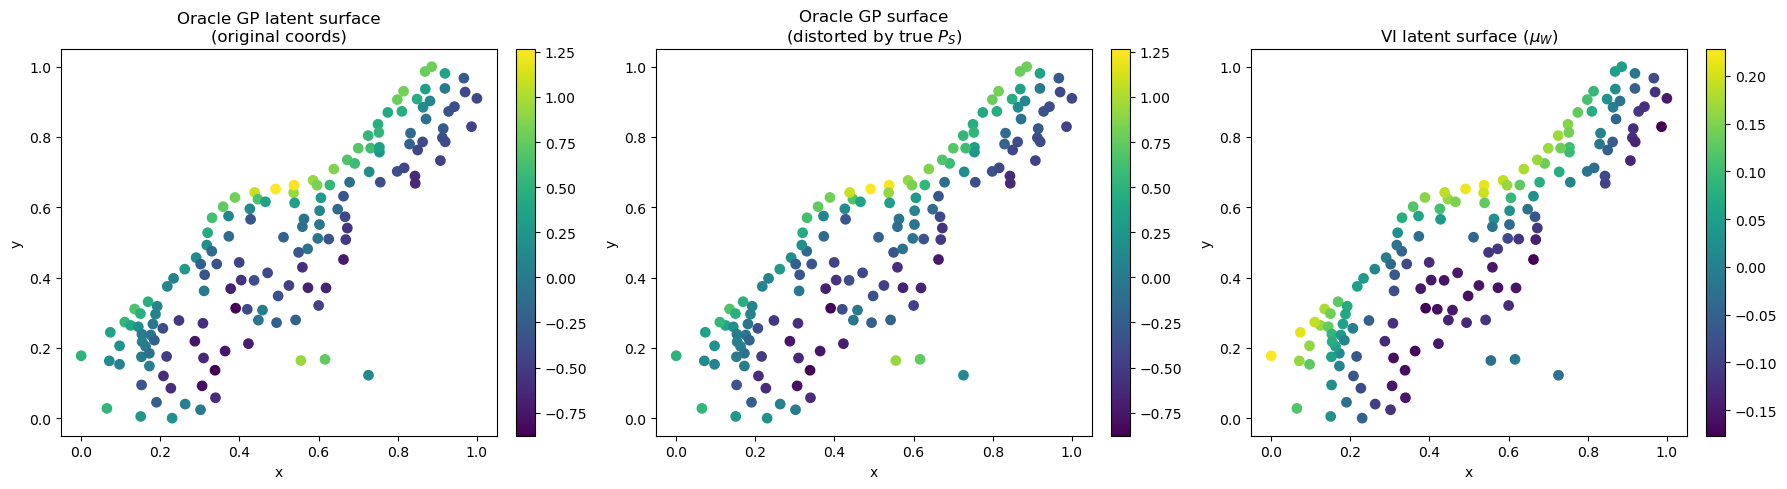

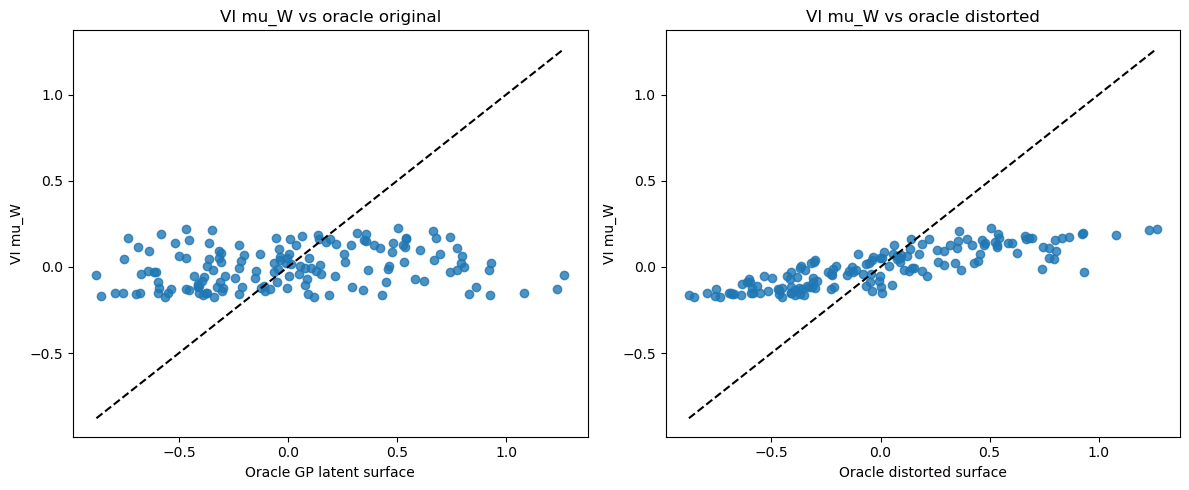

In [20]:
# ============================================================
# STEP 5: Compare latent surfaces
#   - Oracle GP latent surface on original coords
#   - Oracle GP surface distorted by true spatial permutation
#   - VI latent surface mu_W
#
# NOTE:
#   In this real-data notebook, there is no true generative W.
#   So we use the oracle GP posterior mean on original data
#   as the "reference truth".
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Helper 1: block-diagonal spatial permutation matrix
# ------------------------------------------------------------
def make_big_block_perm(P_small, n_blocks):
    """
    Build full block-diagonal permutation:
        P_big = I_B \kron P_small
    where P_small is n_i x n_i.
    """
    P_small = P_small.detach().cpu()
    I_B = torch.eye(n_blocks)
    return torch.kron(I_B, P_small).float()

from utils import round_to_perm

# ------------------------------------------------------------
# Helper 2: GP posterior mean of latent W
# Model:
#   Y = X beta + W + eps
#   W ~ N(0, K), eps ~ N(0, tau^2 I)
# posterior mean:
#   E[W|Y] = K (K + tau^2 I)^(-1) (Y - X beta)
# ------------------------------------------------------------
def gp_posterior_mean_w(coords, X, Y, beta, sigmasq, phi, tausq, jitter=1e-6):
    coords = coords.detach().cpu().float()
    X = X.detach().cpu().float()
    Y = Y.detach().cpu().float().view(-1)

    if X.ndim == 1:
        X = X.unsqueeze(1)

    beta = torch.as_tensor(beta, dtype=torch.float32).view(-1)
    resid = Y - (X @ beta).view(-1)

    D = torch.cdist(coords, coords, p=2)
    K = sigmasq * torch.exp(-phi * D)
    C = K + (tausq + jitter) * torch.eye(K.shape[0])

    mu_w = K @ torch.linalg.solve(C, resid)
    return mu_w


# ------------------------------------------------------------
# Helper 3: recursively search a dict/list/tuple for a key
# containing some substring, e.g. "mu_W"
# ------------------------------------------------------------
def recursive_find(obj, target_substr):
    if isinstance(obj, dict):
        for k, v in obj.items():
            if target_substr.lower() in str(k).lower():
                return v
        for _, v in obj.items():
            out = recursive_find(v, target_substr)
            if out is not None:
                return out

    elif isinstance(obj, (list, tuple)):
        for v in obj:
            out = recursive_find(v, target_substr)
            if out is not None:
                return out

    return None


# ------------------------------------------------------------
# Helper 4: convert candidate VI output to a flat vector
# ------------------------------------------------------------
def to_flat_vector(x, n_expected=None):
    if x is None:
        return None

    if isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    else:
        arr = np.asarray(x)

    arr = np.squeeze(arr)

    # common case: (B, n_i)
    if arr.ndim == 2:
        arr = arr.reshape(-1)

    if n_expected is not None and arr.size != n_expected:
        print(f"[warn] extracted object has length {arr.size}, expected {n_expected}")

    return arr


# ------------------------------------------------------------
# 1) Oracle latent surface on original coordinates
# ------------------------------------------------------------
w_oracle = gp_posterior_mean_w(
    coords=coords_orig,
    X=X_orig,
    Y=Y_orig,
    beta=oracle_params["beta"],
    sigmasq=oracle_params["sigmasq"],
    phi=oracle_params["phi"],
    tausq=oracle_params["tausq"],
)

# ------------------------------------------------------------
# 2) Distort oracle surface with the TRUE spatial permutation
#    used to generate coords_perm from coords_orig
# ------------------------------------------------------------
P_S_big = make_big_block_perm(perm_matrix_s, n_blocks=15)
w_oracle_distorted = (P_S_big @ w_oracle.detach().cpu()).numpy()
w_oracle = w_oracle.detach().cpu().numpy()

# ------------------------------------------------------------
# 3) Extract VI mu_W
#    This tries to find anything named like "mu_W" in vi_results
# ------------------------------------------------------------
mu_W_raw = recursive_find(vi_results, "mu_W")
mu_W_vi = to_flat_vector(mu_W_raw, n_expected=len(w_oracle))

if mu_W_vi is None:
    raise ValueError(
        "Could not find `mu_W` inside `vi_results`. "
        "Run `vi_results.keys()` and inspect the nested structure."
    )

print("Extracted VI mu_W shape:", mu_W_vi.shape)


# ------------------------------------------------------------
# 4) Optional: try to extract estimated spatial permutation
#    from VI output if available
# ------------------------------------------------------------

piS_est = round_to_perm(vi_results['results']['M_S_star'])
 # default to true perm if not found in VI output
#make piS_est tensor if it's numpy
if isinstance(piS_est, np.ndarray):
    piS_est = torch.from_numpy(piS_est).float().to(device)
#create big block permutation from piS_est
P_S_est = make_big_block_perm(piS_est, n_blocks=15)
# ------------------------------------------------------------
# 5) If VI mu_W is already in original latent ordering, compare to w_oracle.
#    If VI mu_W is still in permuted/distorted ordering, compare to w_oracle_distorted.
#
#    Since implementation details may differ, we report BOTH.
# ------------------------------------------------------------
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

def corr(a, b):
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return np.nan
    return np.corrcoef(a, b)[0, 1]

print("\n--- Surface comparison metrics ---")
print("VI mu_W  vs oracle original:")
print("  RMSE =", rmse(mu_W_vi, w_oracle))
print("  Corr =", corr(mu_W_vi, w_oracle))

print("VI mu_W  vs oracle distorted:")
print("  RMSE =", rmse(mu_W_vi, w_oracle_distorted))
print("  Corr =", corr(mu_W_vi, w_oracle_distorted))


# ------------------------------------------------------------
# 6) Visualization
#   Panel A: oracle latent surface on original coords
#   Panel B: oracle surface after true spatial distortion on coords_perm
#   Panel C: VI mu_W on coords_perm
#
# If your VI mu_W is actually on original ordering, replace coords_perm by coords_orig.
# ------------------------------------------------------------
coords_orig_np = coords_orig.detach().cpu().numpy()
coords_perm_np = coords_perm.detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Oracle/original
sc0 = axes[0].scatter(
    coords_orig_np[:, 0], coords_orig_np[:, 1],
    c=w_oracle, s=45
)
axes[0].set_title("Oracle GP latent surface\n(original coords)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(sc0, ax=axes[0], fraction=0.046, pad=0.04)

# Oracle distorted by TRUE spatial permutation
sc1 = axes[1].scatter(
    coords_perm_np[:, 0], coords_perm_np[:, 1],
    c=w_oracle_distorted, s=45
)
axes[1].set_title("Oracle GP surface\n(distorted by true $P_S$)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(sc1, ax=axes[1], fraction=0.046, pad=0.04)

# VI mu_W
sc2 = axes[2].scatter(
    coords_perm_np[:, 0], coords_perm_np[:, 1],
    c=mu_W_vi, s=45
)
axes[2].set_title("VI latent surface ($\\mu_W$)")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
plt.colorbar(sc2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7) Scatter comparisons
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(w_oracle, P_S_est.T @ mu_W_vi, alpha=0.8)
mn = min(w_oracle.min(), mu_W_vi.min())
mx = max(w_oracle.max(), mu_W_vi.max())
axes[0].plot([mn, mx], [mn, mx], 'k--')
axes[0].set_title("VI mu_W vs oracle original")
axes[0].set_xlabel("Oracle GP latent surface")
axes[0].set_ylabel("VI mu_W")

axes[1].scatter(w_oracle_distorted, mu_W_vi, alpha=0.8)
mn = min(w_oracle_distorted.min(), mu_W_vi.min())
mx = max(w_oracle_distorted.max(), mu_W_vi.max())
axes[1].plot([mn, mx], [mn, mx], 'k--')
axes[1].set_title("VI mu_W vs oracle distorted")
axes[1].set_xlabel("Oracle distorted surface")
axes[1].set_ylabel("VI mu_W")

plt.tight_layout()
plt.show()

# save the w's in csv for oracle and P_S_est @ mu_W_vi
import pandas as pd 
df_comparison = pd.DataFrame({
    "w_oracle": w_oracle,
    "w_oracle_distorted": w_oracle_distorted,
    "mu_W_vi": mu_W_vi,
    "mu_W_vi_perm": P_S_est @ mu_W_vi,
})
df_comparison.to_csv("latent_surface_comparison_15_10.csv", index=False)
